<a href="https://colab.research.google.com/github/Kommandjsdf/MachineLearning/blob/main/NLTK/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nltk

In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('movie_reviews')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

In [3]:
from nltk.corpus import movie_reviews
import random

documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

random.shuffle(documents)

In [4]:
print(documents[10])

(['"', 'come', 'on', ',', 'silent', 'bob', '!', 'we', "'", 're', 'going', 'to', 'hollywood', '.', '"', 'starring', 'jason', 'mewes', ',', 'kevin', 'smith', ',', 'will', 'ferrell', ',', 'shannon', 'elizabeth', ',', 'seann', 'william', 'scott', ',', 'chris', 'rock', ',', 'jason', 'lee', ',', 'ben', 'affleck', '.', 'directed', 'by', 'kevin', 'smith', '.', 'rated', 'r', '.', 'jay', 'and', 'silent', 'bob', 'strike', 'back', 'is', 'a', 'dumb', 'movie', 'disguised', 'in', 'a', 'smarmy', 'interior', '.', 'kevin', 'smith', ',', 'coming', 'off', 'the', 'wonderful', ',', 'challenging', 'dogma', ',', 'fills', 'it', 'with', 'sub', '-', 'road', 'trip', 'gross', '-', 'out', 'jokes', 'and', 'expects', 'us', 'to', 'buy', 'it', 'because', 'he', "'", 's', 'just', 'oh', '-', 'so', '-', 'ironic', '.', 'but', 'when', 'a', 'movie', 'is', 'so', 'self', '-', 'aware', 'it', 'becomes', 'about', 'nothing', 'but', 'itself', ',', 'we', 'can', 'hardly', 'be', 'expected', 'to', 'pay', 'for', 'admission', '.', 'jay', 

In [5]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clear_word(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [6]:
print(stop_words)

{'before', 'now', 'you', 'they', 'down', 'during', 'hasn', 'was', 'what', 'doesn', "we're", 'your', 'there', 'my', 'all', 'of', 'shan', "shan't", 'y', 'as', 'don', 'through', 'being', 'than', 'theirs', 'we', 'both', 'him', 'under', 'yourselves', "they're", 'be', "wasn't", 'any', 'which', "don't", 'his', 'is', 'few', 'shouldn', 'by', "couldn't", "that'll", "isn't", 'mightn', 'the', "didn't", 'can', "she'd", "it's", 'didn', 'once', 'for', "he's", 'ourselves', 'same', 'with', "she's", 'hers', 'been', 'ma', 'their', "wouldn't", 'nor', 'mustn', 'such', 'own', 'myself', 'on', 'whom', 'other', "doesn't", 'too', 'most', 'here', 'isn', 'yourself', 'doing', 'only', 'who', 'has', 'just', 'above', 'while', 'o', 'me', 'but', 'a', "hadn't", 'and', "i'll", 'them', "she'll", "needn't", 'himself', 'an', 'until', 'had', 'very', "they've", 'do', "he'll", "weren't", 'each', 'were', 'itself', 'below', 'if', "aren't", 're', 'herself', 'to', 'into', 'her', 'how', "we've", 'over', 'in', "we'd", 's', 'that', "

In [7]:
cleaned_document = [(" ".join(clear_word(document)), category) for document, category in documents]

In [8]:
print(cleaned_document[10])

('come silent bob go hollywood star jason mew kevin smith ferrel shannon elizabeth seann william scott chri rock jason lee ben affleck direct kevin smith rate r jay silent bob strike back dumb movi disguis smarmi interior kevin smith come wonder challeng dogma fill sub road trip gross joke expect us buy oh iron movi self awar becom noth hardli expect pay admiss jay silent bob two new jersey stoner hang doorstep conveni store sell pot appear almost smith movi mistaken star one find movi base comic book base made hollywood present two problem receiv penni royalti b nerd internet internet talk trash except go hollywood stop movi made way hitchhik knew need ticket take bu run group hotti pretend anim right group realli jewel thief parad around charli angel style outfit cours set jay silent bob look like thiev massiv manhunt go second half film ferrel prove incap anyth sketch comedi show wildlif marshal inspector think two stolen monkey movi probabl pleas smith die hard undiscern fan everyo

In [9]:
df = pd.DataFrame(cleaned_document, columns=('Review', 'Label'))
df.head(11)

,Review,Label
0,note may consid portion follow text spoiler fo...,pos
1,may critic aliv harbor much affect shlock mons...,neg
2,mission mar one annoy movi middl movi get snea...,neg
3,may heard luca might think much probabl star c...,pos
4,one respect name american independ filmmak joh...,neg
5,voic trey parker matt stone georg clooney minn...,pos
6,sometim decid write short stori poem think tit...,neg
7,seen trailer commerci rather difficult realli ...,neg
8,capsul world come end midnight everyon know mu...,pos
9,wonder boy michael dougla play age writer prof...,pos


<Axes: xlabel='Label'>

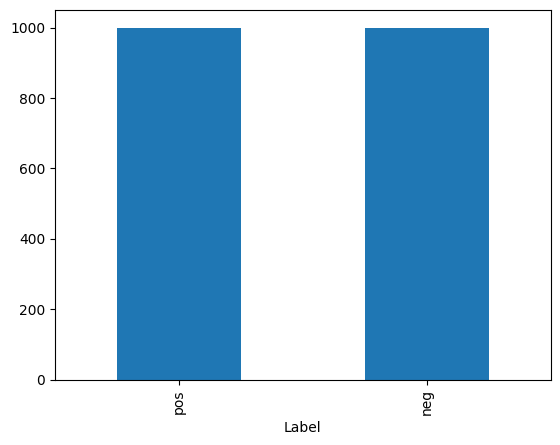

In [10]:
df['Label'].value_counts().plot(kind='bar')

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Review'])
y = df['Label']

In [12]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 15254)	1
  (0, 13655)	2
  (0, 4383)	1
  (0, 16978)	1
  (0, 8007)	2
  (0, 22192)	1
  (0, 20858)	1
  (0, 8081)	1
  (0, 5257)	1
  (0, 597)	2
  (0, 25038)	2
  (0, 6824)	1
  (0, 15685)	1
  (0, 1419)	1
  (0, 18155)	3
  (0, 13303)	1
  (0, 21389)	1
  (0, 14191)	1
  (0, 8629)	2
  (0, 12215)	1
  (0, 5711)	1
  (0, 7714)	35
  (0, 17633)	1
  (0, 20305)	1
  (0, 12828)	2
  :	:
  (1999, 9010)	1
  (1999, 6089)	2
  (1999, 4506)	1
  (1999, 21922)	1
  (1999, 7410)	1
  (1999, 13125)	1
  (1999, 21878)	1
  (1999, 4598)	1
  (1999, 11222)	1
  (1999, 17602)	1
  (1999, 17523)	1
  (1999, 6191)	2
  (1999, 20440)	1
  (1999, 12217)	1
  (1999, 14712)	1
  (1999, 12716)	2
  (1999, 2794)	1
  (1999, 8840)	8
  (1999, 1803)	1
  (1999, 13086)	3
  (1999, 4699)	1
  (1999, 19625)	1
  (1999, 15539)	1
  (1999, 19417)	1
  (1999, 5805)	1
0       pos
1       neg
2       neg
3       pos
4       neg
      

In [19]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_log = LogisticRegression(max_iter=1000)
model_mult = MultinomialNB()

model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)
model_mult.fit(X_train, y_train)
y_pred_mult = model_mult.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix

print('Accuracy log:', accuracy_score(y_test, y_pred_log))
print('Accuracy mult:', accuracy_score(y_test, y_pred_mult))

Accuracy log: 0.8125
Accuracy mult: 0.8225


Text(0.5, 1.0, 'Confusion Matrix Logistic Regression')

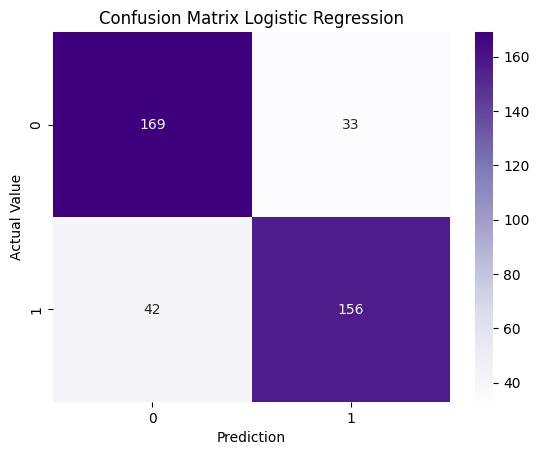

In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Purples')
plt.xlabel('Prediction')
plt.ylabel('Actual Value')
plt.title('Confusion Matrix Logistic Regression')

Text(0.5, 1.0, 'Confusion Matrix Multinominal NB')

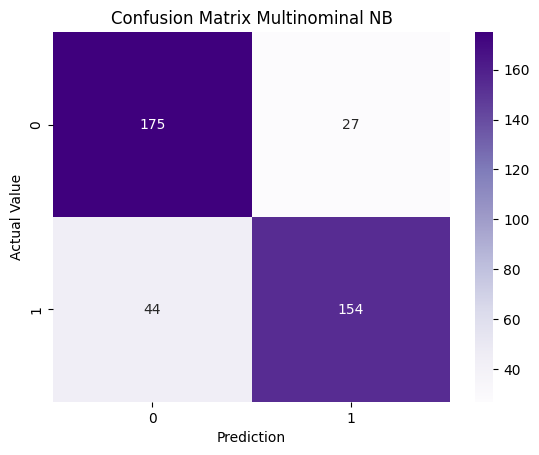

In [22]:
sns.heatmap(confusion_matrix(y_test, y_pred_mult), annot=True, fmt='d', cmap='Purples')
plt.xlabel('Prediction')
plt.ylabel('Actual Value')
plt.title('Confusion Matrix Multinominal NB')

In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
def predict_review_log(text: str) -> str:
  cleaned = " ".join(clear_word(word_tokenize(text)))
  vec = vectorizer.transform([cleaned])
  return model_log.predict(vec)[0]

def predict_review_mult(text: str) -> str:
  cleaned = " ".join(clear_word(word_tokenize(text)))
  vec = vectorizer.transform([cleaned])
  return model_mult.predict(vec)[0]

In [28]:
print(predict_review_log("I like the movie!"))
print(predict_review_log("The story was pretty bad, but everything else was actually good. Good movie just as a movie, but they could've spent the money making a movie about something else"))
print(predict_review_log("I really enjoyed the movie's good vibe"))
print(predict_review_log("The movie is talked about so much for a reason. You definitely won't regret watching this"))
print(predict_review_log("Watching this is a waste of time if you ask me. Only watch this if you're a big fan of the actually good book"))
print(predict_review_log("I wish they made the music better, but I wouldn't say the movie is bad. Very calm and relaxing, especially when watching after a hard day"))
print(predict_review_log("Nothing particularly wrong with this movie, the hate is forced on my opinion. I personally liked it, and the acting isn't as bad as everyone says"))
print(predict_review_log("It's a shame I can't watch this for the first time again, nothing will ever match that feeling. If you haven't watched this, you're missing out"))
print(predict_review_log("Don't watch this if you don't like fiction - you'll just hate it. Everything is very unrealistic and made-up. The actors, the script, the scenes, and everything else was actually good!"))
print(predict_review_log("The movie is awesome if you're looking for a way to waste your time"))

neg
neg
pos
neg
neg
neg
neg
neg
neg
neg


| Review | Naive Bayes | Logistic Regression | Actual |
| -- | -- | -- | -- |
| I like the movie! | neg | neg | pos |
| The story was pretty bad, but everything else was actually good. Good movie just as a movie, but they could've spent the money making a movie about something else | neg | neg | pos |
| I really enjoyed the movie's good vibe | pos | pos | pos |
| The movie is talked about so much for a reason. You definitely won't regret watching this | pos | neg | pos |
| Watching this is a waste of time if you ask me. Only watch this if you're a big fan of the actually good book | neg | neg | neg |
| I wish they made the music better, but I wouldn't say the movie is bad. Very calm and relaxing, especially when watching after a hard day | neg | neg | pos |
| Nothing particularly wrong with this movie, the hate is forced on my opinion. I personally liked it, and the acting isn't as bad as everyone says | neg | neg | pos |
| It's a shame I can't watch this for the first time again, nothing will ever match that feeling. If you haven't watched this, you're missing out | neg | neg | pos |
| Don't watch this if you don't like fiction - you'll just hate it. Everything is very unrealistic and made-up. The actors, the script, the scenes, and everything else was actually good! | neg | neg | pos |
| The movie is awesome if you're looking for a way to waste your time | neg | neg | neg |